In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import lightgbm as lgb
import xgboost as xgb

Training set shape: (614, 8) (614,)
Test set shape: (154, 8) (154,)


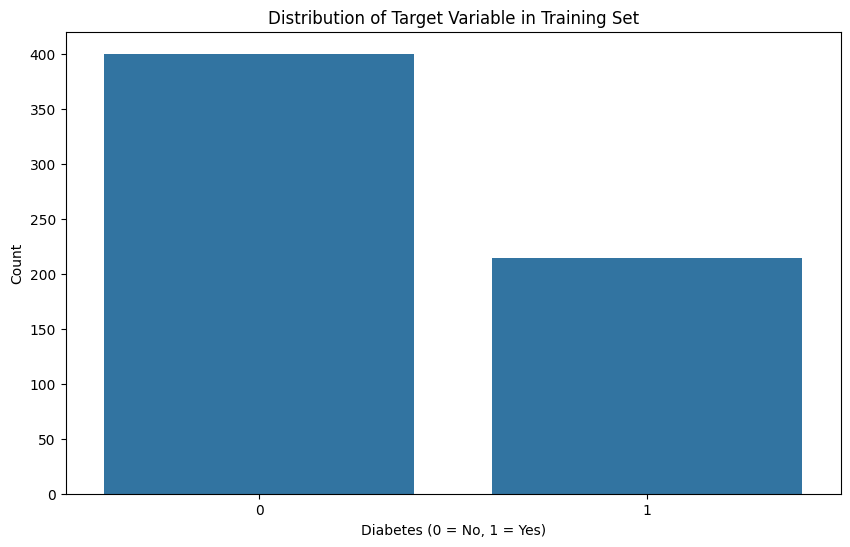

In [5]:
X_train = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_X_train_scaled.csv")
y_train = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_y_train.csv").values.ravel()
X_test = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_X_test_scaled.csv")
y_test = pd.read_csv("../data/preprocessed/pima_preprocessed/pima_y_test.csv").values.ravel()

print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

plt.figure(figsize=(10, 6))
sns.countplot(x=y_train)
plt.title("Distribution of Target Variable in Training Set")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled training set shape: (800, 8) (800,)


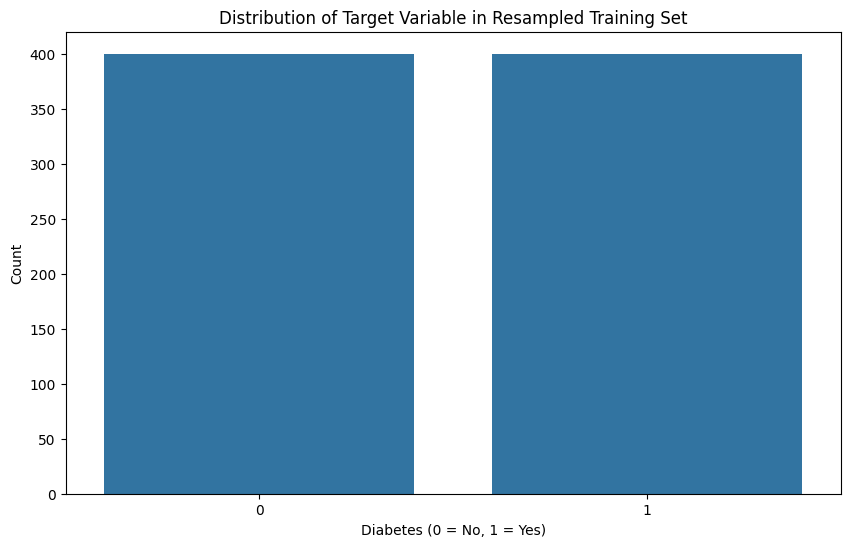

In [6]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train_resampled)
plt.title("Distribution of Target Variable in Resampled Training Set")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [20]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = None

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    
    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
        print(f"AUC-ROC  : {auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return acc, prec, rec, f1, auc

In [16]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight=None)
lr.fit(X_train_resampled, y_train_resampled)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)



Logistic Regression
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1-score : 0.6087
AUC-ROC  : 0.8113

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



(0.7077922077922078,
 0.5737704918032787,
 0.6481481481481481,
 0.6086956521739131,
 np.float64(0.8112962962962964))

In [17]:
lgm = lgb.LGBMClassifier(random_state=42)
lgm.fit(X_train_resampled, y_train_resampled)
lgm_pred = lgm.predict(X_test)
lgm_prob = lgm.predict_proba(X_test)[:, 1]
evaluate_model("LightGBM", y_test, lgm_pred, lgm_prob)

[LightGBM] [Info] Number of positive: 400, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1132
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

(0.7207792207792207,
 0.5964912280701754,
 0.6296296296296297,
 0.6126126126126126,
 np.float64(0.8098148148148148))

In [18]:
xgbr = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgbr.fit(X_train_resampled, y_train_resampled)
xgbr_pred = xgbr.predict(X_test)
xgbr_prob = xgbr.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", y_test, xgbr_pred, xgbr_prob)


XGBoost
Accuracy : 0.7403
Precision: 0.6207
Recall   : 0.6667
F1-score : 0.6429
AUC-ROC  : 0.8189

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.62      0.67      0.64        54

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.74      0.74       154



c:\Users\kiero\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [14:56:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


(0.7402597402597403,
 0.6206896551724138,
 0.6666666666666666,
 0.6428571428571429,
 np.float64(0.8188888888888889))


Logistic Regression
Accuracy : 0.7078
Precision: 0.5738
Recall   : 0.6481
F1-score : 0.6087
AUC-ROC  : 0.8113

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154


LightGBM
Accuracy : 0.7208
Precision: 0.5965
Recall   : 0.6296
F1-score : 0.6126
AUC-ROC  : 0.8098

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154


XGBoost
Accuracy : 0.7403
Precision: 0.6207
Recall   : 0.6667
F1-score : 0.6429
AUC-RO

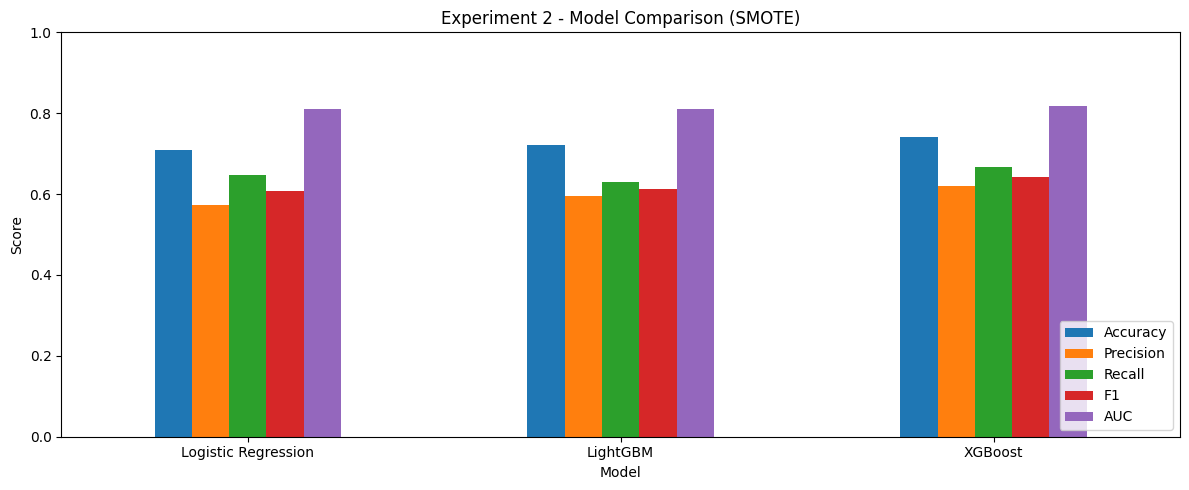

In [23]:
results_exp2 = []

acc, prec, rec, f1, auc = evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
results_exp2.append(["Logistic Regression", acc, prec, rec, f1, auc])

acc, prec, rec, f1, auc = evaluate_model("LightGBM", y_test, lgm_pred, lgm_prob)
results_exp2.append(["LightGBM", acc, prec, rec, f1, auc])

acc, prec, rec, f1, auc = evaluate_model("XGBoost", y_test, xgbr_pred, xgbr_prob)
results_exp2.append(["XGBoost", acc, prec, rec, f1, auc])

columns = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC"]
df_exp2 = pd.DataFrame(results_exp2, columns=columns)
df_exp2

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
df_exp2.set_index("Model")[metrics].plot(kind="bar", figsize=(12, 5))
plt.title("Experiment 2 - Model Comparison (SMOTE)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()